In [1]:
import polars as pl

DATA_GLOB = "data/subset_part_*.parquet"  

In [3]:
lf = pl.scan_parquet(DATA_GLOB)
lf = lf.with_columns(
    pl.from_epoch("unixReviewTime", time_unit="s").alias("review_dt")
)

print(lf.schema)


Schema({'reviewerID': String, 'unixReviewTime': Int64, 'year': Int64, 'overall': Float64, 'asin': String, 'verified': Boolean, 'summary': String, 'reviewText': String, 'review_dt': Datetime(time_unit='us', time_zone=None)})


/var/folders/jc/m5_dzhb94fsdm0nt78jxzpx00000gn/T/ipykernel_73801/1301566362.py:6: PerformanceWarning: Resolving the schema of a LazyFrame is a potentially expensive operation. Use `LazyFrame.collect_schema()` to get the schema without this warning.
  print(lf.schema)


In [4]:
overview = lf.select([
    pl.len().alias("n_reviews"),
    pl.col("reviewerID").n_unique().alias("n_users"),
    pl.col("asin").n_unique().alias("n_products"),
    pl.min("year").alias("min_year"),
    pl.max("year").alias("max_year"),
]).collect()

print(overview)


shape: (1, 5)
┌───────────┬─────────┬────────────┬──────────┬──────────┐
│ n_reviews ┆ n_users ┆ n_products ┆ min_year ┆ max_year │
│ ---       ┆ ---     ┆ ---        ┆ ---      ┆ ---      │
│ u32       ┆ u32     ┆ u32        ┆ i64      ┆ i64      │
╞═══════════╪═════════╪════════════╪══════════╪══════════╡
│ 200000    ┆ 125233  ┆ 94636      ┆ 2018     ┆ 2018     │
└───────────┴─────────┴────────────┴──────────┴──────────┘


In [5]:
missing = lf.select([
    pl.all().null_count()
]).collect()
print(missing)


shape: (1, 9)
┌────────────┬────────────────┬──────┬─────────┬───┬──────────┬─────────┬────────────┬───────────┐
│ reviewerID ┆ unixReviewTime ┆ year ┆ overall ┆ … ┆ verified ┆ summary ┆ reviewText ┆ review_dt │
│ ---        ┆ ---            ┆ ---  ┆ ---     ┆   ┆ ---      ┆ ---     ┆ ---        ┆ ---       │
│ u32        ┆ u32            ┆ u32  ┆ u32     ┆   ┆ u32      ┆ u32     ┆ u32        ┆ u32       │
╞════════════╪════════════════╪══════╪═════════╪═══╪══════════╪═════════╪════════════╪═══════════╡
│ 0          ┆ 0              ┆ 0    ┆ 0       ┆ … ┆ 0        ┆ 106     ┆ 284        ┆ 0         │
└────────────┴────────────────┴──────┴─────────┴───┴──────────┴─────────┴────────────┴───────────┘


In [6]:
print(lf.group_by("overall").agg(pl.len().alias("n")).sort("overall").collect())
print(lf.group_by("year").agg(pl.len().alias("n")).sort("year").collect())


shape: (5, 2)
┌─────────┬────────┐
│ overall ┆ n      │
│ ---     ┆ ---    │
│ f64     ┆ u32    │
╞═════════╪════════╡
│ 1.0     ┆ 21204  │
│ 2.0     ┆ 10295  │
│ 3.0     ┆ 13762  │
│ 4.0     ┆ 22904  │
│ 5.0     ┆ 131835 │
└─────────┴────────┘
shape: (1, 2)
┌──────┬────────┐
│ year ┆ n      │
│ ---  ┆ ---    │
│ i64  ┆ u32    │
╞══════╪════════╡
│ 2018 ┆ 200000 │
└──────┴────────┘


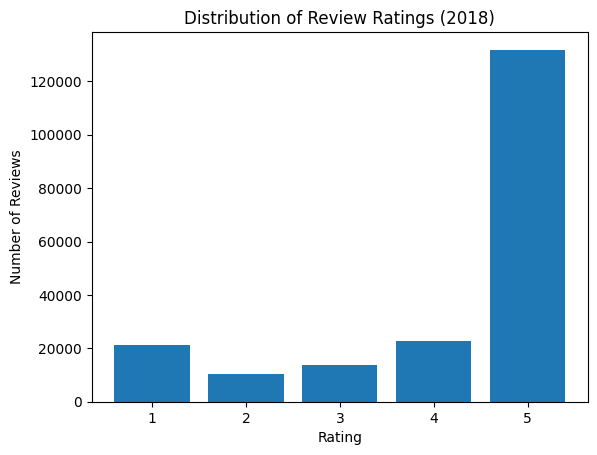

In [7]:
import matplotlib.pyplot as plt
import os

os.makedirs("images", exist_ok=True)

rating_counts = (
    lf.group_by("overall")
      .agg(pl.len().alias("n"))
      .sort("overall")
      .collect()
      .to_pandas()
)

plt.figure()
plt.bar(rating_counts["overall"], rating_counts["n"])
plt.xlabel("Rating")
plt.ylabel("Number of Reviews")
plt.title("Distribution of Review Ratings (2018)")
plt.xticks([1, 2, 3, 4, 5])

plt.savefig("images/rating_distribution.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()

In [8]:
user_counts = lf.group_by("reviewerID").agg(pl.len().alias("n_reviews"))

print(
    user_counts.select([
        pl.len().alias("total_users"),
        (pl.col("n_reviews") == 1).mean().alias("pct_one_review"),
        (pl.col("n_reviews") >= 2).mean().alias("pct_two_plus"),
        pl.col("n_reviews").median().alias("median_reviews_per_user"),
        pl.col("n_reviews").quantile(0.9).alias("p90_reviews_per_user"),
    ]).collect()
)


shape: (1, 5)
┌─────────────┬────────────────┬──────────────┬─────────────────────────┬──────────────────────┐
│ total_users ┆ pct_one_review ┆ pct_two_plus ┆ median_reviews_per_user ┆ p90_reviews_per_user │
│ ---         ┆ ---            ┆ ---          ┆ ---                     ┆ ---                  │
│ u32         ┆ f64            ┆ f64          ┆ f64                     ┆ f64                  │
╞═════════════╪════════════════╪══════════════╪═════════════════════════╪══════════════════════╡
│ 125233      ┆ 0.724442       ┆ 0.275558     ┆ 1.0                     ┆ 3.0                  │
└─────────────┴────────────────┴──────────────┴─────────────────────────┴──────────────────────┘


In [9]:
# First review date per user
first = (
    lf.group_by("reviewerID")
      .agg(pl.col("review_dt").min().alias("first_review_dt"))
)

NEW_DAYS = 90

lf2 = (
    lf.join(first, on="reviewerID", how="inner")
      .with_columns(
          (pl.col("review_dt") - pl.col("first_review_dt")).dt.total_days().alias("account_age_days")
      )
)

new_user_reviews = lf2.filter(pl.col("account_age_days") <= NEW_DAYS)

# Early vs late windows (within first 90 days)
early_end = 30
late_start, late_end = 60, 90

user_change = (
    new_user_reviews
      .with_columns(
          pl.when(pl.col("account_age_days") <= early_end).then(pl.lit("early"))
            .when((pl.col("account_age_days") >= late_start) & (pl.col("account_age_days") <= late_end)).then(pl.lit("late"))
            .otherwise(None)
            .alias("period")
      )
      .filter(pl.col("period").is_not_null())
      .group_by(["reviewerID", "period"])
      .agg(pl.mean("overall").alias("avg_rating"))
      .collect()  # pivot happens on eager DF
      .pivot(index="reviewerID", columns="period", values="avg_rating")
      .drop_nulls(["early", "late"])  # keep only users with both 
      .with_columns((pl.col("late") - pl.col("early")).alias("delta_rating"))
)

print(
    user_change.select([
        pl.len().alias("n_users_with_both_windows"),
        pl.col("delta_rating").mean().alias("mean_delta"),
        pl.col("delta_rating").median().alias("median_delta"),
        pl.col("delta_rating").quantile(0.25).alias("q25"),
        pl.col("delta_rating").quantile(0.75).alias("q75"),
    ])
)


shape: (1, 5)
┌───────────────────────────┬────────────┬──────────────┬───────────┬─────┐
│ n_users_with_both_windows ┆ mean_delta ┆ median_delta ┆ q25       ┆ q75 │
│ ---                       ┆ ---        ┆ ---          ┆ ---       ┆ --- │
│ u32                       ┆ f64        ┆ f64          ┆ f64       ┆ f64 │
╞═══════════════════════════╪════════════╪══════════════╪═══════════╪═════╡
│ 3661                      ┆ 0.017225   ┆ 0.0          ┆ -0.166667 ┆ 0.5 │
└───────────────────────────┴────────────┴──────────────┴───────────┴─────┘


/var/folders/jc/m5_dzhb94fsdm0nt78jxzpx00000gn/T/ipykernel_73801/2066555837.py:34: DeprecationWarning: the argument `columns` for `DataFrame.pivot` is deprecated. It was renamed to `on` in version 1.0.0.
  .pivot(index="reviewerID", columns="period", values="avg_rating")


In [10]:
# summary stats:
summary = user_change.select([
    pl.len().alias("n_users"),
    pl.col("early").mean().alias("mean_early"),
    pl.col("late").mean().alias("mean_late"),
    pl.col("delta_rating").mean().alias("mean_delta"),
    pl.col("delta_rating").median().alias("median_delta"),
    pl.col("delta_rating").std().alias("sd_delta"),
    (pl.col("delta_rating") > 0).mean().alias("pct_improve"),
    (pl.col("delta_rating") < 0).mean().alias("pct_decline"),
    (pl.col("delta_rating") == 0).mean().alias("pct_no_change"),
    pl.col("delta_rating").quantile(0.25).alias("q25"),
    pl.col("delta_rating").quantile(0.75).alias("q75"),
]).to_pandas()

print(summary)

   n_users  mean_early  mean_late  mean_delta  median_delta  sd_delta  \
0     3661    4.261658   4.278883    0.017225           0.0  1.472504   

   pct_improve  pct_decline  pct_no_change       q25  q75  
0     0.283802     0.253756       0.462442 -0.166667  0.5  


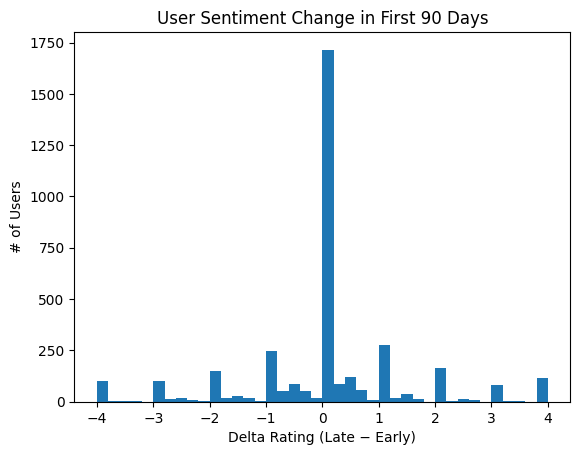

In [11]:
import matplotlib.pyplot as plt
import os

os.makedirs("images", exist_ok=True)

# Extract delta values
delta = user_change.select("delta_rating").to_pandas()["delta_rating"]

plt.figure()
plt.hist(delta, bins=40)
plt.xlabel("Delta Rating (Late − Early)")
plt.ylabel("# of Users")
plt.title("User Sentiment Change in First 90 Days")

plt.savefig("images/delta_histogram.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()

In [12]:
# Initial Statistical Test
# Determine if mean delta differs from 0 for individual users (t-test)
from scipy import stats

delta = user_change.select("delta_rating").to_pandas()["delta_rating"]

t_stat, p_val = stats.ttest_1samp(delta, 0)

print("t-stat:", t_stat)
print("p-value:", p_val)


t-stat: 0.7077993525348047
p-value: 0.47911493720136883


In [13]:
# Add first review per user
first_ratings = (
    lf
    .sort(["reviewerID", "review_dt"])
    .group_by("reviewerID")
    .agg(pl.first("overall").alias("first_rating"))
    .collect()
)

In [14]:
# Group by first rating
analysis = (
    user_change
    .join(first_ratings, on="reviewerID")
    .group_by("first_rating")
    .agg([
        pl.len().alias("n"),
        pl.col("delta_rating").mean().alias("mean_delta"),
        pl.col("delta_rating").median().alias("median_delta"),
        (pl.col("delta_rating") > 0).mean().alias("pct_improve"),
        (pl.col("delta_rating") < 0).mean().alias("pct_decline")
    ])
    .sort("first_rating")
)

print(analysis)

shape: (5, 6)
┌──────────────┬──────┬────────────┬──────────────┬─────────────┬─────────────┐
│ first_rating ┆ n    ┆ mean_delta ┆ median_delta ┆ pct_improve ┆ pct_decline │
│ ---          ┆ ---  ┆ ---        ┆ ---          ┆ ---         ┆ ---         │
│ f64          ┆ u32  ┆ f64        ┆ f64          ┆ f64         ┆ f64         │
╞══════════════╪══════╪════════════╪══════════════╪═════════════╪═════════════╡
│ 1.0          ┆ 312  ┆ 2.230118   ┆ 2.5          ┆ 0.775641    ┆ 0.051282    │
│ 2.0          ┆ 167  ┆ 1.394582   ┆ 1.5          ┆ 0.748503    ┆ 0.143713    │
│ 3.0          ┆ 274  ┆ 0.687318   ┆ 1.0          ┆ 0.718978    ┆ 0.222628    │
│ 4.0          ┆ 459  ┆ 0.124304   ┆ 0.5          ┆ 0.586057    ┆ 0.261438    │
│ 5.0          ┆ 2449 ┆ -0.453659  ┆ 0.0          ┆ 0.084116    ┆ 0.289098    │
└──────────────┴──────┴────────────┴──────────────┴─────────────┴─────────────┘


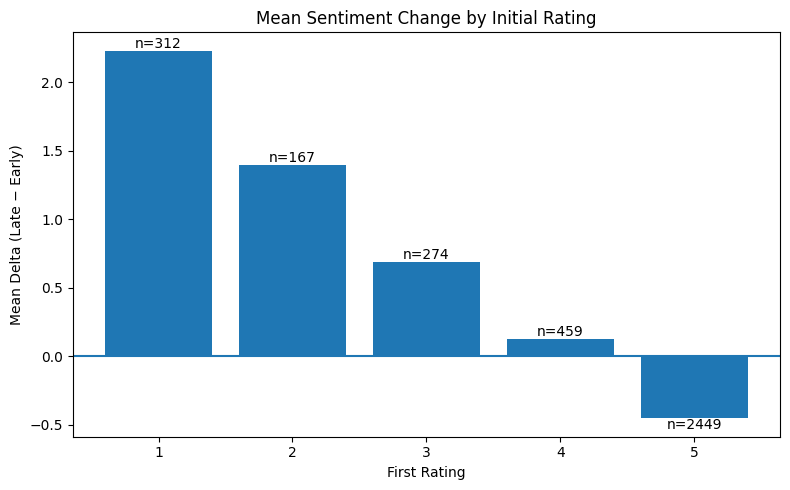

In [15]:
import matplotlib.pyplot as plt
import os

os.makedirs("images", exist_ok=True)

analysis_pd = analysis.to_pandas()
analysis_pd = analysis_pd.sort_values("first_rating")

plt.figure(figsize=(8, 5))

bars = plt.bar(
    analysis_pd["first_rating"].astype(int),
    analysis_pd["mean_delta"]
)

plt.axhline(0)

for _, row in analysis_pd.iterrows():
    plt.text(
        int(row["first_rating"]),
        row["mean_delta"],
        f'n={int(row["n"])}',
        ha='center',
        va='bottom' if row["mean_delta"] >= 0 else 'top'
    )

plt.xlabel("First Rating")
plt.ylabel("Mean Delta (Late − Early)")
plt.title("Mean Sentiment Change by Initial Rating")
plt.xticks([1, 2, 3, 4, 5])
plt.tight_layout()

plt.savefig("images/review_grouped_barplot.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()

In [21]:
# Second Statistical Test
# Determine if mean delta differs from 0 for each first rating group (t-test)
# Second Statistical Test
# Determine if mean delta differs from 0 for each first rating group (t-test)

import pandas as pd
from scipy import stats

subgroup_df = (
    user_change
    .join(first_ratings, on="reviewerID")
    .select(["first_rating", "delta_rating"])
)

df = subgroup_df.to_pandas()

results = []

for rating, group in df.groupby("first_rating"):
    deltas = group["delta_rating"]

    t_stat, p_val = stats.ttest_1samp(deltas, 0)

    results.append({
        "first_rating": rating,
        "n": len(deltas),
        "mean_delta": deltas.mean(),
        "sd_delta": deltas.std(ddof=1),
        "t_stat": t_stat,
        "p_value": p_val
    })

results_df = pd.DataFrame(results).sort_values("first_rating")
print(results_df)

   first_rating     n  mean_delta  sd_delta     t_stat       p_value
0           1.0   312    2.230118  1.768859  22.269579  2.349457e-66
1           2.0   167    1.394582  1.489696  12.097754  1.465689e-24
2           3.0   274    0.687318  1.394083   8.161012  1.229408e-14
3           4.0   459    0.124304  1.141339   2.333332  2.006267e-02
4           5.0  2449   -0.453659  1.097988 -20.446838  6.456831e-86


In [22]:
# Confidence Intervals for mean delta by first rating group
# Confidence Intervals for mean delta by first rating group

import numpy as np
from scipy import stats
import pandas as pd

ci_results = []

for rating, group in df.groupby("first_rating"):
    deltas = group["delta_rating"]

    n = len(deltas)
    mean = deltas.mean()
    std = deltas.std(ddof=1)
    se = std / np.sqrt(n)

    ci_low, ci_high = stats.t.interval(
        confidence=0.95,
        df=n - 1,
        loc=mean,
        scale=se
    )

    ci_results.append({
        "first_rating": rating,
        "n": n,
        "mean_delta": mean,
        "se": se,
        "ci_low": ci_low,
        "ci_high": ci_high
    })

ci_df = pd.DataFrame(ci_results).sort_values("first_rating")
print(ci_df)

   first_rating     n  mean_delta        se    ci_low   ci_high
0           1.0   312    2.230118  0.100142  2.033077  2.427159
1           2.0   167    1.394582  0.115276  1.166986  1.622179
2           3.0   274    0.687318  0.084220  0.521515  0.853120
3           4.0   459    0.124304  0.053273  0.019614  0.228994
4           5.0  2449   -0.453659  0.022187 -0.497167 -0.410151


In [ ]:
# Final merged table
final_subgroup_results = results_df.merge(
    ci_df[["first_rating", "ci_low", "ci_high"]],
    on="first_rating"
)

print(final_subgroup_results)

   first_rating     n  mean_delta  sd_delta     t_stat       p_value  \
0           1.0   312    2.230118  1.768859  22.269579  2.349457e-66   
1           2.0   167    1.394582  1.489696  12.097754  1.465689e-24   
2           3.0   274    0.687318  1.394083   8.161012  1.229408e-14   
3           4.0   459    0.124304  1.141339   2.333332  2.006267e-02   
4           5.0  2449   -0.453659  1.097988 -20.446838  6.456831e-86   

     ci_low   ci_high  
0  2.033077  2.427159  
1  1.166986  1.622179  
2  0.521515  0.853120  
3  0.019614  0.228994  
4 -0.497167 -0.410151  


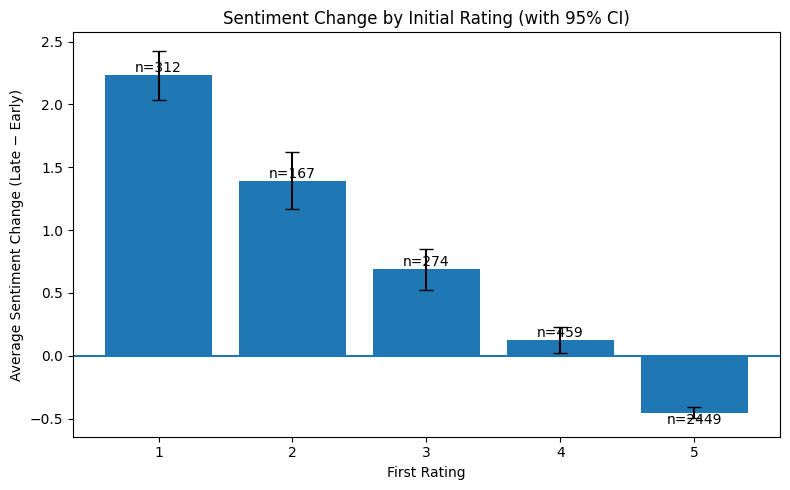

In [25]:
import matplotlib.pyplot as plt
import pandas as pd

plot_df = final_subgroup_results.sort_values("first_rating").copy()

# Convert CI bounds into error bar lengths
plot_df["err_low"] = plot_df["mean_delta"] - plot_df["ci_low"]
plot_df["err_high"] = plot_df["ci_high"] - plot_df["mean_delta"]

errors = [plot_df["err_low"], plot_df["err_high"]]

plt.figure(figsize=(8, 5))

plt.bar(
    plot_df["first_rating"].astype(int),
    plot_df["mean_delta"],
    yerr=errors,
    capsize=5
)

plt.axhline(0)

for _, row in plot_df.iterrows():
    plt.text(
        int(row["first_rating"]),
        row["mean_delta"],
        f'n={int(row["n"])}',
        ha='center',
        va='bottom' if row["mean_delta"] >= 0 else 'top'
    )

plt.xlabel("First Rating")
plt.ylabel("Average Sentiment Change (Late − Early)")
plt.title("Sentiment Change by Initial Rating (with 95% CI)")
plt.xticks([1, 2, 3, 4, 5])
plt.tight_layout()

plt.savefig("images/review_grouped_barplot_ci.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()